# 04 - Model Training & Evaluation

Train Linear Regression, Random Forest, XGBoost with spatial cross-validation. Feature importance and failure analysis.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from src.data_loader import load_features
from src.models import (
    train_linear_regression,
    train_random_forest,
    train_xgboost,
    get_feature_importance
)
from src.evaluation import (
    spatial_cross_validate,
    compute_metrics,
    paired_ttest,
    identify_failure_cases,
    plot_predicted_vs_actual,
    plot_feature_importance
)
from src.utils import get_data_dir, get_experiments_dir
import joblib

try:
    X_df, y = load_features()
except FileNotFoundError:
    from src.features import build_feature_matrix
    from src.synthetic_data import generate_synthetic_dataset
    df = generate_synthetic_dataset()
    X_df, y = build_feature_matrix(df)

if 'field_id' in X_df.columns:
    field_ids = X_df['field_id'].astype(str).values
    feature_cols = [c for c in X_df.columns if c != 'field_id']
else:
    # Fallback when loader already removed field_id.
    field_ids = np.array([f'field_{i}' for i in range(len(X_df))])
    feature_cols = list(X_df.columns)

X = X_df[feature_cols].fillna(0).values
y = y.values
le = LabelEncoder()
groups = le.fit_transform(field_ids)

## 1. Spatial Cross-Validation

## 2. Statistical Comparison (Paired t-test)

In [3]:
t_stat, p_val = paired_ttest(y, yp_rf, yp_xgb)
print(f'Paired t-test RF vs XGBoost: t={t_stat:.4f}, p={p_val:.4f}')
print('XGBoost significantly better' if p_val < 0.05 else 'No significant difference')

Paired t-test RF vs XGBoost: t=-0.9033, p=0.3686
No significant difference


## 3. Predicted vs Actual & Feature Importance

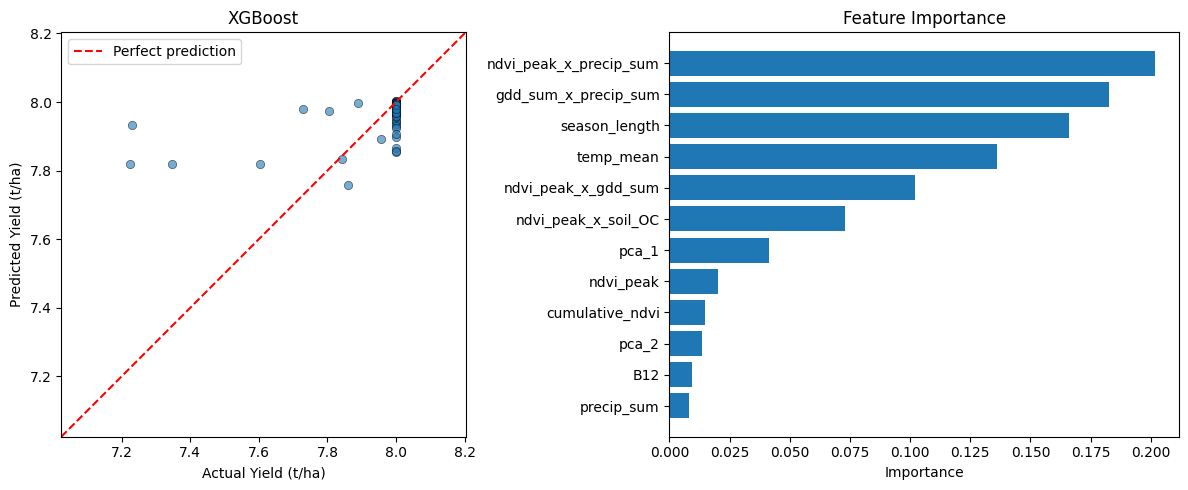

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_predicted_vs_actual(y, yp_xgb, ax=axes[0], title='XGBoost')
imp_df = get_feature_importance(m_xgb, feature_cols)
plot_feature_importance(imp_df, ax=axes[1], top_n=12)
plt.tight_layout()
plt.savefig(get_experiments_dir() / 'results' / 'predictions_and_importance.png', dpi=150)
plt.show()

## 4. Failure Analysis

In [5]:
failure_df = identify_failure_cases(X_df, y, yp_xgb, field_ids, n_worst=5)
print('Worst prediction errors:')
print(failure_df)

Worst prediction errors:
   field_id    y_true    y_pred  abs_error
0  field_40  7.230348  7.933613   0.703264
1  field_26  7.223882  7.820495   0.596613
2  field_83  7.346552  7.818700   0.472148
3  field_54  7.729690  7.979880   0.250190
4  field_73  7.604484  7.820331   0.215847


In [6]:
# Save best model
get_experiments_dir().mkdir(parents=True, exist_ok=True)
(get_experiments_dir() / 'results').mkdir(exist_ok=True)
joblib.dump(m_xgb, get_experiments_dir() / 'results' / 'best_model_xgb.joblib')
print('Saved best model to experiments/results/best_model_xgb.joblib')

Saved best model to experiments/results/best_model_xgb.joblib
